In [1]:
!pip install textblob pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import pandas as pd
from textblob import TextBlob

In [121]:
def detect_emotion(text):
    
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity
    
    if polarity > 0:
        return "Happy"
    
    elif polarity == 0:
        return "Neutral"
    
    else:
        return "Sad"

In [122]:
text = input("How are you feeling today? ")

emotion = detect_emotion(text)

print("Detected Emotion:", emotion)

How are you feeling today?  very tired


Detected Emotion: Sad


In [123]:
from textblob import TextBlob

def detect_emotion(text):

    text = text.lower()
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    # keyword based emotions
    if "stress" in text or "overwhelmed" in text:
        return "Stressed"
    
    if "angry" in text or "mad" in text:
        return "Angry"
    
    if "tired" in text or "exhausted" in text:
        return "Tired"
    
    if "excited" in text or "energetic" in text:
        return "Excited"

    # sentiment based emotions
    if polarity > 0.3:
        return "Happy"
    
    elif polarity < -0.3:
        return "Sad"
    
    else:
        return "Neutral"


text = input("How are you feeling today? ")

emotion = detect_emotion(text)

print("Detected Emotion:", emotion)

How are you feeling today?  very tired


Detected Emotion: Tired


In [124]:
def suggest_task(emotion):

    if emotion == "Excited" or emotion == "Happy":
        return "Good time to work on important tasks."

    if emotion == "Stressed":
        return "Take a short break or do light work."

    if emotion == "Tired":
        return "Rest for a while."

    if emotion == "Sad":
        return "Try a relaxing activity."

    return "You can continue normal tasks."

In [125]:
suggestion = suggest_task(emotion)

print("Detected Emotion:", emotion)
print("Suggestion:", suggestion)

Detected Emotion: Tired
Suggestion: Rest for a while.


In [126]:
from textblob import TextBlob
import csv
from datetime import datetime

def detect_emotion(text):

    text = text.lower()
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    if "stress" in text:
        return "Stressed"
    
    if "tired" in text:
        return "Tired"

    if "excited" in text or "energetic" in text:
        return "Excited"

    if polarity > 0.3:
        return "Happy"
    
    elif polarity < -0.3:
        return "Sad"
    
    else:
        return "Neutral"


text = input("How are you feeling today? ")

emotion = detect_emotion(text)

print("Detected Emotion:", emotion)

# store history
time_now = datetime.now()

with open("emotion_history.csv", "a", newline="") as file:
    writer = csv.writer(file)
    writer.writerow([time_now, text, emotion])

How are you feeling today?  very tired


Detected Emotion: Tired


In [127]:
import pandas as pd

df = pd.read_csv("emotion_history.csv")

df.head()

,2026-03-14 16:32:25.244111,i feel energetic,Excited
0,2026-03-16 10:22:15.990924,i feel stressed today,Stressed
1,2026-03-16 10:22:41.760080,feeling tired today,Tired
2,2026-03-16 10:23:28.032504,feel neutral today,Neutral
3,2026-03-16 10:23:57.053300,feeling happy about today,Happy
4,2026-03-16 10:24:29.717127,feeling excited,Excited


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   2026-03-14 16:32:25.244111  15 non-null     object
 1   i feel energetic            15 non-null     object
 2   Excited                     15 non-null     object
dtypes: object(3)
memory usage: 492.0+ bytes


In [129]:
df.columns

Index(['2026-03-14 16:32:25.244111', 'i feel energetic', 'Excited'], dtype='object')

In [130]:
import pandas as pd

df = pd.read_csv("emotion_history.csv", header=None,
                 names=["Time", "Text", "Emotion"])

print(df.head())

                         Time                       Text   Emotion
0  2026-03-14 16:32:25.244111           i feel energetic   Excited
1  2026-03-16 10:22:15.990924      i feel stressed today  Stressed
2  2026-03-16 10:22:41.760080        feeling tired today     Tired
3  2026-03-16 10:23:28.032504         feel neutral today   Neutral
4  2026-03-16 10:23:57.053300  feeling happy about today     Happy


In [131]:
df["Emotion"].value_counts()

Emotion
Happy       8
Excited     3
Tired       2
Stressed    1
Neutral     1
Sad         1
Name: count, dtype: int64

In [132]:
df["Time"] = pd.to_datetime(df["Time"])

In [133]:
df["Hour"] = df["Time"].dt.hour

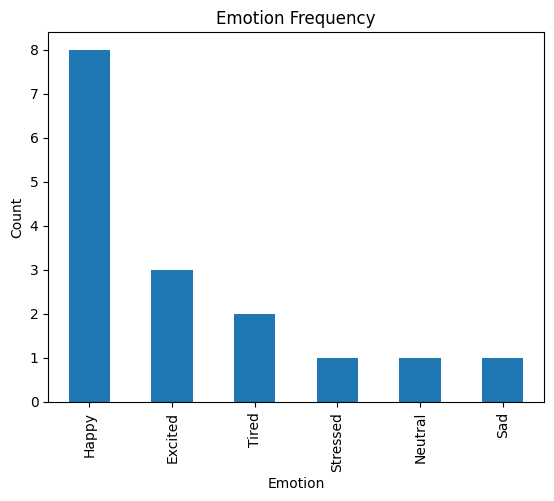

In [134]:
import matplotlib.pyplot as plt

df["Emotion"].value_counts().plot(kind="bar")

plt.title("Emotion Frequency")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

In [135]:
df["Emotion"].mode()

0    Happy
Name: Emotion, dtype: object

In [136]:
df.head()


,Time,Text,Emotion,Hour
0,2026-03-14 16:32:25.244111,i feel energetic,Excited,16
1,2026-03-16 10:22:15.990924,i feel stressed today,Stressed,10
2,2026-03-16 10:22:41.760080,feeling tired today,Tired,10
3,2026-03-16 10:23:28.032504,feel neutral today,Neutral,10
4,2026-03-16 10:23:57.053300,feeling happy about today,Happy,10


In [137]:
def suggest_task(emotion):

    if emotion == "Excited":
        return "Great energy! Work on difficult or high-focus tasks."

    elif emotion == "Happy":
        return "Good mood! Continue with productive tasks."

    elif emotion == "Neutral":
        return "You can handle routine tasks."

    elif emotion == "Tired":
        return "Try lighter tasks or take a short rest."

    elif emotion == "Stressed":
        return "Take a short break or do relaxing activities."

    else:
        return "Proceed with normal tasks."

In [138]:
suggestion = suggest_task(emotion)

print("Detected Emotion:", emotion)
print("Task Suggestion:", suggestion)

Detected Emotion: Tired
Task Suggestion: Try lighter tasks or take a short rest.


In [139]:
emotion_score = {
    "Excited": 5,
    "Happy": 4,
    "Neutral": 3,
    "Tired": 2,
    "Stressed": 1
}

df["ProductivityScore"] = df["Emotion"].map(emotion_score)
df.head()

,Time,Text,Emotion,Hour,ProductivityScore
0,2026-03-14 16:32:25.244111,i feel energetic,Excited,16,5.0
1,2026-03-16 10:22:15.990924,i feel stressed today,Stressed,10,1.0
2,2026-03-16 10:22:41.760080,feeling tired today,Tired,10,2.0
3,2026-03-16 10:23:28.032504,feel neutral today,Neutral,10,3.0
4,2026-03-16 10:23:57.053300,feeling happy about today,Happy,10,4.0


In [140]:
df.groupby("Hour")["ProductivityScore"].mean()

Hour
10    3.166667
11    4.000000
12    4.500000
16    5.000000
21    4.000000
22    3.500000
Name: ProductivityScore, dtype: float64

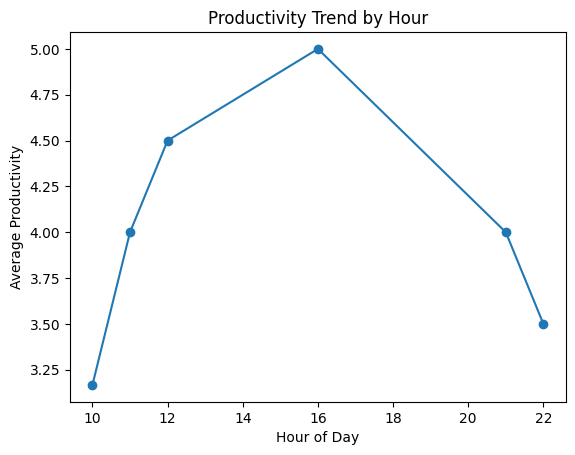

In [141]:
import matplotlib.pyplot as plt

df.groupby("Hour")["ProductivityScore"].mean().plot(kind="line", marker="o")

plt.title("Productivity Trend by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Productivity")

plt.show()

In [142]:
def suggest_task(emotion):

    if emotion == "Excited":
        return "Best time for deep work or difficult tasks"

    elif emotion == "Happy":
        return "Good time to work on important tasks"

    elif emotion == "Neutral":
        return "You can do routine tasks"

    elif emotion == "Tired":
        return "Try lighter tasks"

    elif emotion == "Stressed":
        return "Take a short break"

    else:
        return "Continue normal tasks"

In [143]:
suggestion = suggest_task(emotion)

print("Detected Emotion:", emotion)
print("Task Suggestion:", suggestion)

Detected Emotion: Tired
Task Suggestion: Try lighter tasks


In [144]:
def suggest_task(emotion):

    task_map = {
        "Excited": "Do deep focus tasks like coding or studying.",
        "Happy": "Work on important tasks or projects.",
        "Neutral": "You can complete routine tasks.",
        "Tired": "Do light tasks or small activities.",
        "Stressed": "Take a short break or relax."
    }

    return task_map.get(emotion, "Continue normal work.")

In [145]:
df["Emotion"].value_counts()

Emotion
Happy       8
Excited     3
Tired       2
Stressed    1
Neutral     1
Sad         1
Name: count, dtype: int64

In [146]:
df.groupby("Hour")["ProductivityScore"].mean().idxmax()

np.int32(16)

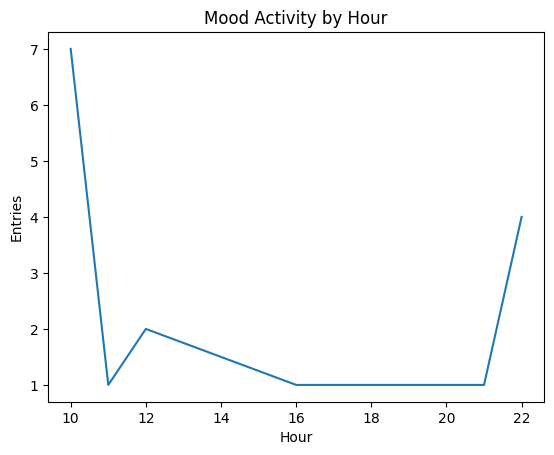

In [147]:
df.groupby("Hour")["Emotion"].count().plot(kind="line")

plt.title("Mood Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Entries")

plt.show()

In [148]:
def daily_report(df):

    print("Daily Emotion Summary")

    print("Most frequent emotion:")
    print(df["FinalEmotion"].mode()[0])

    print("Average productivity:")
    print(df["ProductivityScore"].mean())

    best_hour = df.groupby("Hour")["ProductivityScore"].mean().idxmax()

    print("Most productive hour:", best_hour)

In [149]:
df.columns


Index(['Time', 'Text', 'Emotion', 'Hour', 'ProductivityScore'], dtype='object')

In [150]:
import pandas as pd

df = pd.read_csv("emotion_history.csv", header=None)

df.columns = ["Time", "Text", "Emotion"]

print(df.head())

                         Time                       Text   Emotion
0  2026-03-14 16:32:25.244111           i feel energetic   Excited
1  2026-03-16 10:22:15.990924      i feel stressed today  Stressed
2  2026-03-16 10:22:41.760080        feeling tired today     Tired
3  2026-03-16 10:23:28.032504         feel neutral today   Neutral
4  2026-03-16 10:23:57.053300  feeling happy about today     Happy


In [151]:
df["Time"] = pd.to_datetime(df["Time"])
df["Hour"] = df["Time"].dt.hour

In [152]:
import pandas as pd

# Load CSV without header
df = pd.read_csv("emotion_history.csv", header=None)

# Assign column names
df.columns = ["Time", "Text", "Emotion"]

# Convert time column
df["Time"] = pd.to_datetime(df["Time"])

# Extract hour
df["Hour"] = df["Time"].dt.hour

In [153]:
emotion_score = {
    "Excited": 5,
    "Happy": 4,
    "Neutral": 3,
    "Tired": 2,
    "Stressed": 1
}

df["ProductivityScore"] = df["Emotion"].map(emotion_score)

In [154]:
def daily_report(df):

    print("------ Daily Emotion Summary ------")

    print("\nMost frequent emotion:")
    print(df["Emotion"].mode()[0])

    print("\nAverage productivity:")
    print(df["ProductivityScore"].mean())

    best_hour = df.groupby("Hour")["ProductivityScore"].mean().idxmax()

    print("\nMost productive hour:", best_hour)

In [155]:
daily_report(df)

------ Daily Emotion Summary ------

Most frequent emotion:
Happy

Average productivity:
3.6666666666666665

Most productive hour: 16


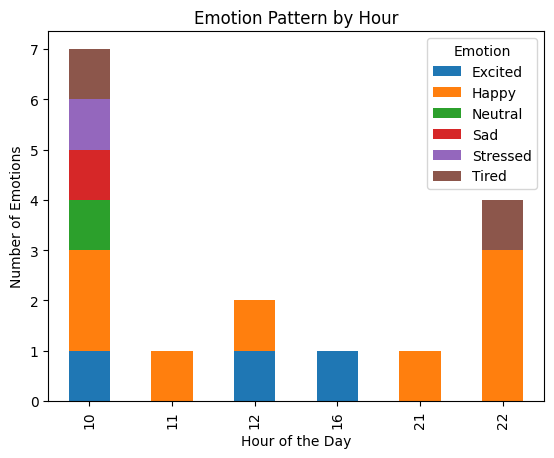

In [156]:
import matplotlib.pyplot as plt

# count emotions by hour
emotion_by_hour = df.groupby(["Hour", "Emotion"]).size().unstack()

emotion_by_hour.plot(kind="bar", stacked=True)

plt.title("Emotion Pattern by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Emotions")

plt.show()

In [157]:
!pip install opencv-python
!pip install deepface
!pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [158]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [159]:
!pip install tensorflow==2.12.0
!pip install deepface
!pip install opencv-python

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow==2.12.0



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [162]:
import cv2
from deepface import DeepFace

In [163]:
img = cv2.imread("face.jpg")

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

print("Faces detected:", len(faces))

Faces detected: 1


In [164]:
result = DeepFace.analyze(img_path="face.jpg", actions=['emotion'])

face_emotion = result[0]['dominant_emotion']
print("Face Emotion:", face_emotion)

Face Emotion: neutral


In [165]:
text_emotion = "happy"   # from your text model

In [166]:
if text_emotion == face_emotion:
    final_emotion = text_emotion
else:
    final_emotion = "mixed"

print("Final Emotion:", final_emotion)

Final Emotion: mixed


In [167]:
df["FaceEmotion"] = face_emotion
df["FinalEmotion"] = final_emotion

In [168]:
def daily_report(df):

    print("Daily Emotion Summary")

    print("Most frequent final emotion:")
    print(df["FinalEmotion"].mode()[0])

    print("Average productivity:")
    print(df["ProductivityScore"].mean())

    best_hour = df.groupby("Hour")["ProductivityScore"].mean().idxmax()

    print("Most productive hour:", best_hour)

In [169]:
print(df.columns)

Index(['Time', 'Text', 'Emotion', 'Hour', 'ProductivityScore', 'FaceEmotion',
       'FinalEmotion'],
      dtype='object')


In [170]:
# Example values (replace with your actual outputs)
text_emotion = df["Emotion"]   # your existing text emotion
face_emotion = "happy"         # from DeepFace (example)

# Create FaceEmotion column
df["FaceEmotion"] = face_emotion

# Create FinalEmotion column
df["FinalEmotion"] = df.apply(
    lambda row: row["Emotion"] if row["Emotion"] == face_emotion else "mixed",
    axis=1
)

In [171]:
df.columns


Index(['Time', 'Text', 'Emotion', 'Hour', 'ProductivityScore', 'FaceEmotion',
       'FinalEmotion'],
      dtype='object')

In [172]:
daily_report(df)

Daily Emotion Summary
Most frequent final emotion:
mixed
Average productivity:
3.6666666666666665
Most productive hour: 16


In [173]:
df

,Time,Text,Emotion,Hour,ProductivityScore,FaceEmotion,FinalEmotion
0,2026-03-14 16:32:25.244111,i feel energetic,Excited,16,5.0,happy,mixed
1,2026-03-16 10:22:15.990924,i feel stressed today,Stressed,10,1.0,happy,mixed
2,2026-03-16 10:22:41.760080,feeling tired today,Tired,10,2.0,happy,mixed
3,2026-03-16 10:23:28.032504,feel neutral today,Neutral,10,3.0,happy,mixed
4,2026-03-16 10:23:57.053300,feeling happy about today,Happy,10,4.0,happy,mixed
5,2026-03-16 10:24:29.717127,feeling excited,Excited,10,5.0,happy,mixed
6,2026-03-16 10:42:59.899149,i feel exhausted,Sad,10,NaN,happy,mixed
7,2026-03-16 10:52:44.626553,feeling happy,Happy,10,4.0,happy,mixed
8,2026-03-16 11:06:11.421998,feeling good,Happy,11,4.0,happy,mixed
9,2026-03-16 12:00:59.782421,good,Happy,12,4.0,happy,mixed


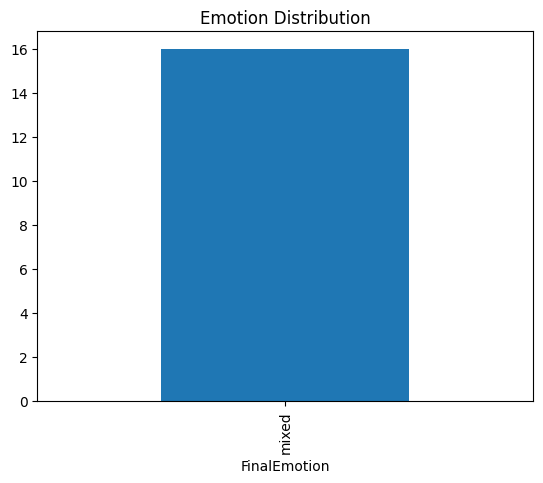

In [174]:
import matplotlib.pyplot as plt

df["FinalEmotion"].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.show()

In [175]:
df.to_csv("emotion_data.csv", index=False)

In [176]:
print(df[["Emotion", "FaceEmotion", "FinalEmotion"]])

     Emotion FaceEmotion FinalEmotion
0    Excited       happy        mixed
1   Stressed       happy        mixed
2      Tired       happy        mixed
3    Neutral       happy        mixed
4      Happy       happy        mixed
5    Excited       happy        mixed
6        Sad       happy        mixed
7      Happy       happy        mixed
8      Happy       happy        mixed
9      Happy       happy        mixed
10   Excited       happy        mixed
11     Happy       happy        mixed
12     Happy       happy        mixed
13     Happy       happy        mixed
14     Happy       happy        mixed
15     Tired       happy        mixed


In [177]:
import cv2
from deepface import DeepFace

In [178]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    
    if not ret:
        break
    
    result = DeepFace.analyze(frame, actions=['emotion'], enforce_detection=False)
    emotion = result[0]['dominant_emotion']
    
    print("Emotion:", emotion)
    
    cv2.imshow("Frame", frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: angry
Emotion: sad
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral
Emotion: neutral


In [87]:
!pip install SpeechRecognition pyaudio


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [88]:
import speech_recognition as sr

def speech_to_text():
    
    recognizer = sr.Recognizer()
    
    with sr.Microphone() as source:
        print("Speak something...")
        audio = recognizer.listen(source)
    
    try:
        text = recognizer.recognize_google(audio)
        print("You said:", text)
        return text
    
    except:
        print("Sorry, could not understand")
        return ""

In [182]:
speech_text = speech_to_text()

speech_emotion = detect_emotion(speech_text)

print("Speech Emotion:", speech_emotion)

Speak something...
Sorry, could not understand
Speech Emotion: Neutral


In [184]:
def final_emotion(text_emotion, face_emotion, speech_emotion):
    
    emotions = [text_emotion, face_emotion, speech_emotion]
    
    if "Stressed" in emotions:
        return "Stressed"
    
    if emotions.count("Sad") >= 2:
        return "Sad"
    
    if emotions.count("Happy") >= 2:
        return "Happy"
    
    return "Neutral"

In [201]:
def final_emotion(text_emotion, face_emotion, speech_emotion):
    
    emotions = [text_emotion, face_emotion, speech_emotion]
    
    # Priority for stress-related emotions
    if any(e in ["Stressed", "Sad", "Tired"] for e in emotions):
        return "Stressed"
    
    # If majority is happy
    if emotions.count("Happy") >= 2:
        return "Happy"
    
    # If mixed signals
    return "Neutral"

In [202]:
text = input("Enter your feeling: ")
text_emotion = detect_emotion(text)

face_emotion = "Happy"   # or your model output
speech_emotion = "Sad"   # or your speech output


Enter your feeling:  very tired


In [203]:
final_emotion_value = final_emotion(text_emotion, face_emotion, speech_emotion)

print("Final Emotion:", final_emotion_value)

Final Emotion: Stressed


In [204]:
def recommend_task(emotion):

    tasks = {
        "Happy": "Work on creative or complex tasks",
        "Neutral": "Continue regular work",
        "Sad": "Do simple or low-effort tasks",
        "Stressed": "Take a break or do light tasks"
    }

    return tasks.get(emotion, "General tasks")

In [218]:
task = recommend_task(final_emotion_value)

print("Task:", task)


Task: Take a break or do light tasks


In [219]:
data = {
    "Time": [datetime.now()],
    "TextEmotion": [text_emotion],
    "FaceEmotion": [face_emotion],
    "SpeechEmotion": [speech_emotion],
    "FinalEmotion": [final_emotion_value],
    "Task": [task]
}

df.head()

df = pd.DataFrame(data)

df.to_csv("mood_data.csv", mode="a", header=False, index=False)

print("Data saved successfully")

Data saved successfully


In [220]:
import pandas as pd

df = pd.read_csv("emotion_data.csv")
df.head()

,Time,Text,Emotion,Hour,ProductivityScore,FaceEmotion,FinalEmotion
0,2026-03-14 16:32:25.244111,i feel energetic,Excited,16,5.0,happy,mixed
1,2026-03-16 10:22:15.990924,i feel stressed today,Stressed,10,1.0,happy,mixed
2,2026-03-16 10:22:41.760080,feeling tired today,Tired,10,2.0,happy,mixed
3,2026-03-16 10:23:28.032504,feel neutral today,Neutral,10,3.0,happy,mixed
4,2026-03-16 10:23:57.053300,feeling happy about today,Happy,10,4.0,happy,mixed


In [221]:
print(df.columns)

Index(['Time', 'Text', 'Emotion', 'Hour', 'ProductivityScore', 'FaceEmotion',
       'FinalEmotion'],
      dtype='object')


In [222]:
import pandas as pd

df = pd.read_csv("mood_data.csv", header=None)

df.columns = ["Time", "TextEmotion", "FaceEmotion", "SpeechEmotion", "FinalEmotion", "Task"]

df.head()

,Time,TextEmotion,FaceEmotion,SpeechEmotion,FinalEmotion,Task
0,2026-03-21 22:42:30.850030,Happy,Happy,Sad,Sad,Do simple or low-effort tasks
1,2026-03-21 22:46:39.226646,Happy,Happy,Sad,Happy,Work on creative or complex tasks
2,2026-03-21 22:50:16.687267,Tired,Happy,Sad,Neutral,Continue regular work
3,2026-03-21 23:00:12.219879,Tired,Happy,Sad,Stressed,Take a break or do light tasks
4,2026-03-21 23:02:53.143548,Tired,Happy,Sad,Stressed,Take a break or do light tasks


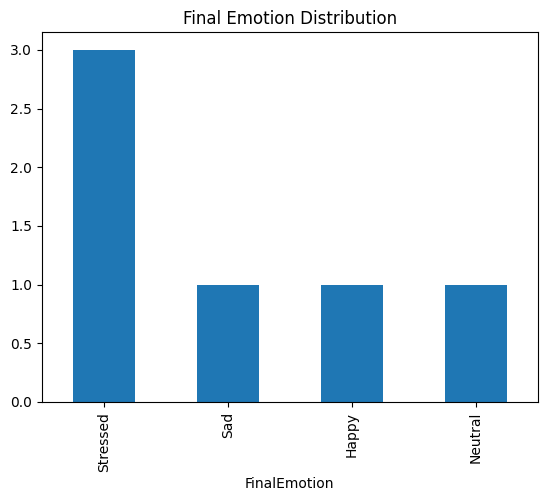

In [223]:
import matplotlib.pyplot as plt

df["FinalEmotion"].value_counts().plot(kind="bar")
plt.title("Final Emotion Distribution")
plt.show()

In [224]:
df.to_csv("mood_data_clean.csv", index=False)

In [225]:
stress_count = (df["FinalEmotion"] == "Stressed").sum()

print("Stress Count:", stress_count)

Stress Count: 3


In [226]:
if stress_count >= 3:
    print("⚠ ALERT: High stress detected!")
    print("Manager should be notified.")
else:
    print("Stress level is normal.")

⚠ ALERT: High stress detected!
Manager should be notified.


In [228]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [229]:
import streamlit as st

st.title("My App")
st.write("Hello World")

2026-03-22 12:25:43.170 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:25:43.556 
  command:

    streamlit run C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-22 12:25:43.558 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:25:43.559 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:25:43.561 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:25:43.562 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-22 12:25:43.563 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
